In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import ast
from pathlib import Path

import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import LinearLR
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from sklearn.metrics import f1_score

# --- Config (edit as needed) ---
DATA_DIR = Path('/content/drive/MyDrive/Colab/NLP/data')  # or Path("../data") if notebook is in a subfolder
TEACHER_MODEL = "bert-base-uncased"
STUDENT_MODEL = "distilbert-base-uncased"
BATCH_SIZE = 8
MAX_LENGTH = 256
EPOCHS = 5
TEMPERATURE = 2.0
LR = 2e-5

# ---------------------------------------------------------------------------
# Teacher training hyperparameters
# ---------------------------------------------------------------------------
TEACHER_LR = 2e-7  # kept low for gradual loss decrease; raise to 5e-7 or 1e-6 if too slow
TEACHER_EPOCHS = 5
TEACHER_BATCH_SIZE = 2
TEACHER_GRADIENT_ACCUMULATION_STEPS = 8  # effective batch = 2 * 8 = 16
TEACHER_WEIGHT_DECAY = 0.01
TEACHER_WARMUP_RATIO = 0.2  # longer warmup for gentler start

# ---------------------------------------------------------------------------
# Distillation hyperparameters
# ---------------------------------------------------------------------------
STUDENT_LR = 5e-6
STUDENT_EPOCHS = 10
STUDENT_BATCH_SIZE = 32
TEMPERATURE = 4.0
ALPHA = 0.7  # weight for soft-label (KL) loss; (1-ALPHA) for hard-label (CE) loss

OUTPUT_DIR = Path("outputs")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [61]:
# Import necessary libraries
from google.colab import userdata
import os

# Get the HF_TOKEN from Colab secrets
hf_token = userdata.get('HF_TOKEN')

# Set it as an environment variable
if hf_token:
    os.environ['HF_TOKEN'] = hf_token
    print("Hugging Face token successfully loaded from Colab secrets and set as environment variable.")
else:
    print("HF_TOKEN not found in Colab secrets. Please add it via the '🔑' icon on the left sidebar.")

Hugging Face token successfully loaded from Colab secrets and set as environment variable.


# PCL Knowledge Distillation

Self-contained notebook: load data, train teacher (BERT), distill to student (DistilBERT) for binary PCL vs non-PCL classification. No external Python files required.

**Run from project root** so `data/` is found, or set `DATA_DIR` below to your data path.

## 1. Imports and config

## 2. Load data and build dataloaders

In [62]:
def load_pcl_splits(data_dir):
    """Load train/dev with text and binary label (0=non-PCL, 1=PCL)."""
    train = pd.read_csv(data_dir / "train_semeval_parids-labels.csv")
    dev = pd.read_csv(data_dir / "dev_semeval_parids-labels.csv")
    tsv = pd.read_csv(
        data_dir / "dontpatronizeme_pcl.tsv",
        sep="\t",
        skiprows=4,
        names=["id", "art_id", "keyword", "country", "text", "label_tsv"],
    )
    tsv["id"] = tsv["id"].astype(int)

    def add_binary_label(df):
        label_col = [c for c in df.columns if "label" in c.lower()][0]
        df = df.copy()
        df["label_vec"] = df[label_col].apply(ast.literal_eval)
        df["binary_label"] = df["label_vec"].apply(lambda v: 1 if sum(v) > 0 else 0)
        return df

    train = add_binary_label(train)
    dev = add_binary_label(dev)
    train = train.merge(tsv[["id", "text"]], left_on="par_id", right_on="id", how="inner").drop(columns=["id"], errors="ignore")
    dev = dev.merge(tsv[["id", "text"]], left_on="par_id", right_on="id", how="inner").drop(columns=["id"], errors="ignore")
    train = train[["text", "binary_label"]].rename(columns={"binary_label": "label"})
    dev = dev[["text", "binary_label"]].rename(columns={"binary_label": "label"})
    return train, dev


class PCLDataset(Dataset):
    def __init__(self, df, tokenizer, max_length):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row["text"]) if pd.notna(row["text"]) else ""
        label = int(row["label"])
        enc = self.tokenizer(text, max_length=self.max_length, padding="max_length", truncation=True, return_tensors="pt")
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }


train_df, dev_df = load_pcl_splits(DATA_DIR)
print(f"Train: {len(train_df)} samples, Dev: {len(dev_df)} samples")

Train: 8375 samples, Dev: 2094 samples


## 3. Load teacher and build dataloaders

In [63]:
tokenizer = AutoTokenizer.from_pretrained(TEACHER_MODEL)
teacher = AutoModelForSequenceClassification.from_pretrained(TEACHER_MODEL, num_labels=2)
teacher = teacher.to(DEVICE)

train_ds = PCLDataset(train_df, tokenizer, MAX_LENGTH)
dev_ds = PCLDataset(dev_df, tokenizer, MAX_LENGTH)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
dev_loader = DataLoader(dev_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("Dataloaders ready.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Dataloaders ready.


## 4. Helper: accuracy and F1

In [ ]:
def accuracy_and_f1(preds, labels):
    preds, labels = preds.cpu(), labels.cpu()
    acc = (preds == labels).float().mean().item()
    tp = ((preds == 1) & (labels == 1)).sum().item()
    fp = ((preds == 1) & (labels == 0)).sum().item()
    fn = ((preds == 0) & (labels == 1)).sum().item()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1_1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    tn = ((preds == 0) & (labels == 0)).sum().item()
    fn0 = ((preds == 1) & (labels == 0)).sum().item()
    fp0 = ((preds == 0) & (labels == 1)).sum().item()
    prec0 = tn / (tn + fp0) if (tn + fp0) > 0 else 0.0
    rec0 = tn / (tn + fn0) if (tn + fn0) > 0 else 0.0
    f1_0 = 2 * prec0 * rec0 / (prec0 + rec0) if (prec0 + rec0) > 0 else 0.0
    return acc, (f1_0 + f1_1) / 2.0

def evaluate(model, dataloader, device):
    """Run evaluation and return loss, accuracy, and macro-F1."""
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item() * labels.size(0)

            preds = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(all_labels)
    accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, accuracy, macro_f1

## 5. Train teacher (cross-entropy)

In [ ]:
teacher_dir = OUTPUT_DIR / "teacher"
teacher_dir.mkdir(parents=True, exist_ok=True)

optimizer = AdamW(teacher.parameters(), lr=LR)
scheduler = LinearLR(optimizer, start_factor=1.0, end_factor=0.1, total_iters=len(train_loader) * EPOCHS)
history_teacher = {"train_loss": [], "dev_loss": [], "dev_acc": [], "dev_f1": []}
best_f1 = 0.0

for epoch in range(EPOCHS):
    teacher.train()
    train_loss_sum = 0.0
    n_steps = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        out = teacher(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        out.loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss_sum += out.loss.item()
    history_teacher["train_loss"].append(train_loss_sum / len(train_loader))

    teacher.eval()
    dev_loss_sum = 0.0
    all_preds, all_labels = [], []
    avg_train_loss = train_loss_sum / n_steps if n_steps else float("nan")
    dev_loss, dev_acc, dev_f1 = evaluate(teacher, dev_loader, DEVICE)
    print(
        f"  Train loss: {avg_train_loss:.4f}  |  "
        f"Dev loss: {dev_loss:.4f}  |  Dev acc: {dev_acc:.4f}  |  Dev F1: {dev_f1:.4f}"
    )   
    # with torch.no_grad():
    #     for batch in dev_loader:
    #         input_ids = batch["input_ids"].to(DEVICE)
    #         attention_mask = batch["attention_mask"].to(DEVICE)
    #         labels = batch["labels"].to(DEVICE)
    #         out = teacher(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
    #         dev_loss_sum += out.loss.item()
    #         all_preds.append(out.logits.argmax(dim=-1))
    #         all_labels.append(labels)
    # history_teacher["dev_loss"].append(dev_loss_sum / len(dev_loader))
    # preds_cat = torch.cat(all_preds, dim=0)
    # labels_cat = torch.cat(all_labels, dim=0)
    # acc, f1 = accuracy_and_f1(preds_cat, labels_cat)
    # history_teacher["dev_acc"].append(acc)
    # history_teacher["dev_f1"].append(f1)

    if dev_f1 > best_f1:
        best_f1 = dev_f1
        teacher.save_pretrained(teacher_dir)
        tokenizer.save_pretrained(teacher_dir)
        print(f"  -> Saved new best teacher (F1={best_f1:.4f}) to {teacher_dir}")


print(f"Teacher saved to {teacher_dir}")
print(f"\nTraining complete.  Best dev macro-F1: {best_f1:.4f}")


Epoch 1/5:   0%|          | 0/1047 [00:00<?, ?it/s]

RuntimeError: Expected all tensors to be on the same device, but got index is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA__index_select)

In [43]:
from tqdm.auto import tqdm
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import f1_score

In [44]:
def evaluate(model, dataloader, device):
    """Run evaluation and return loss, accuracy, and macro-F1."""
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item() * labels.size(0)

            preds = outputs.logits.argmax(dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / len(all_labels)
    # The accuracy_and_f1 function handles accuracy and returns (acc, f1_macro)
    # We'll use this custom one for consistency with previous cells, or adapt if sklearn.metrics.f1_score is preferred for macro-F1
    # For now, let's use the provided f1_score from sklearn.metrics for macro-F1
    accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    return avg_loss, accuracy, macro_f1

## 6. Distillation loss and load teacher from checkpoint

In [35]:
def distillation_loss(student_logits, teacher_logits, labels, temperature, alpha):
    hard = torch.nn.functional.cross_entropy(student_logits, labels)
    T = temperature
    soft_teacher = torch.softmax(teacher_logits / T, dim=-1)
    log_soft_student = torch.log_softmax(student_logits / T, dim=-1)
    soft = torch.nn.functional.kl_div(log_soft_student, soft_teacher, reduction="batchmean") * (T * T)
    return alpha * hard + (1.0 - alpha) * soft


# Load trained teacher from disk (no grad)
teacher = AutoModelForSequenceClassification.from_pretrained(teacher_dir)
teacher = teacher.to(DEVICE)
teacher.eval()

student = AutoModelForSequenceClassification.from_pretrained(STUDENT_MODEL, num_labels=2)
student = student.to(DEVICE)
print("Teacher (from checkpoint) and student loaded.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Teacher (from checkpoint) and student loaded.


## 7. Train student with distillation

In [36]:
student_dir = OUTPUT_DIR / "student_distilled"
student_dir.mkdir(parents=True, exist_ok=True)

optimizer_s = AdamW(student.parameters(), lr=LR)
scheduler_s = LinearLR(optimizer_s, start_factor=1.0, end_factor=0.1, total_iters=len(train_loader) * EPOCHS)
history_student = {"train_loss": [], "dev_loss": [], "dev_acc": [], "dev_f1": []}
best_f1_s = -1.0

for epoch in range(EPOCHS):
    student.train()
    train_loss_sum = 0.0
    for batch in train_loader:
        optimizer_s.zero_grad()
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        with torch.no_grad():
            teacher_logits = teacher(input_ids=input_ids, attention_mask=attention_mask).logits
        student_logits = student(input_ids=input_ids, attention_mask=attention_mask).logits
        loss = distillation_loss(student_logits, teacher_logits, labels, TEMPERATURE, ALPHA)
        loss.backward()
        optimizer_s.step()
        scheduler_s.step()
        train_loss_sum += loss.item()
    history_student["train_loss"].append(train_loss_sum / len(train_loader))

    student.eval()
    dev_loss_sum = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dev_loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            teacher_logits = teacher(input_ids=input_ids, attention_mask=attention_mask).logits
            student_out = student(input_ids=input_ids, attention_mask=attention_mask)
            loss = distillation_loss(student_out.logits, teacher_logits, labels, TEMPERATURE, ALPHA)
            dev_loss_sum += loss.item()
            all_preds.append(student_out.logits.argmax(dim=-1))
            all_labels.append(labels)
    history_student["dev_loss"].append(dev_loss_sum / len(dev_loader))
    preds_cat = torch.cat(all_preds, dim=0)
    labels_cat = torch.cat(all_labels, dim=0)
    acc, f1 = accuracy_and_f1(preds_cat, labels_cat)
    history_student["dev_acc"].append(acc)
    history_student["dev_f1"].append(f1)

    if f1 > best_f1_s:
        best_f1_s = f1
        student.save_pretrained(student_dir)
        tokenizer.save_pretrained(student_dir)
    print(f"Epoch {epoch+1}/{EPOCHS}  train_loss={history_student['train_loss'][-1]:.4f}  dev_acc={acc:.4f}  dev_f1={f1:.4f}")

print(f"Student saved to {student_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/5  train_loss=0.4566  dev_acc=0.9188  dev_f1=0.6539


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 2/5  train_loss=0.2514  dev_acc=0.9207  dev_f1=0.6925
Epoch 3/5  train_loss=0.0805  dev_acc=0.9155  dev_f1=0.6532


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 4/5  train_loss=0.0295  dev_acc=0.9121  dev_f1=0.7071


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 5/5  train_loss=0.0181  dev_acc=0.9126  dev_f1=0.7155
Student saved to outputs/student_distilled


## 8. Optional: plot training curves

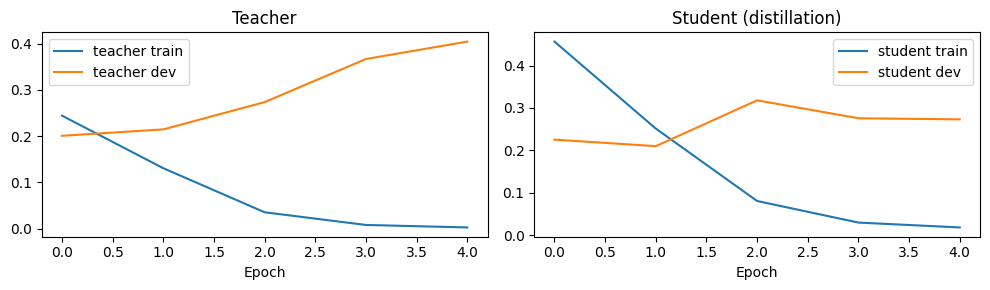

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(history_teacher["train_loss"], label="teacher train")
axes[0].plot(history_teacher["dev_loss"], label="teacher dev")
axes[0].set_title("Teacher")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(history_student["train_loss"], label="student train")
axes[1].plot(history_student["dev_loss"], label="student dev")
axes[1].set_title("Student (distillation)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()